In [33]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [34]:
image3 = cv2.imread('sar_1_gray.jpeg')

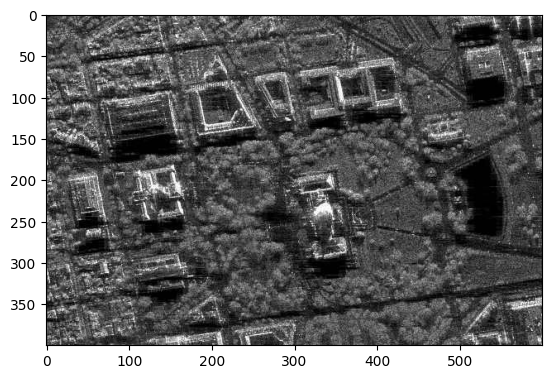

In [35]:
plt.imshow(image3)

In [36]:
b,g,r = cv2.split(image3)

In [37]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

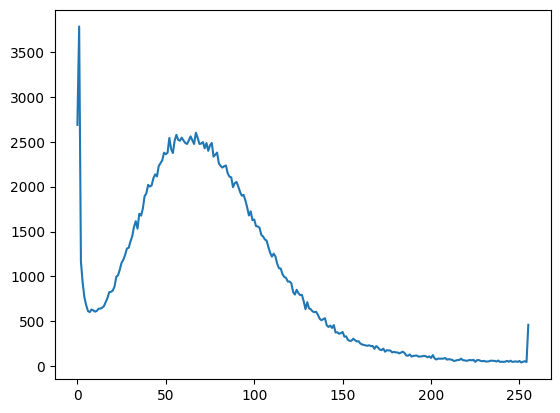

In [38]:
plt.plot(b_hist)

In [39]:
b_hist_cum = b_hist.cumsum()

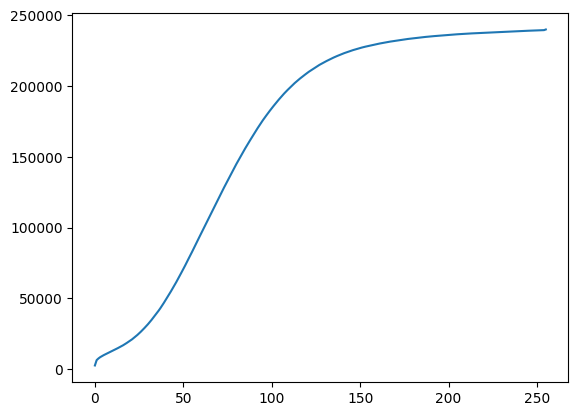

In [40]:
plt.plot(b_hist_cum)

In [41]:
b_hist_norm = b_hist /  (image3.shape[0] * image3.shape[1])

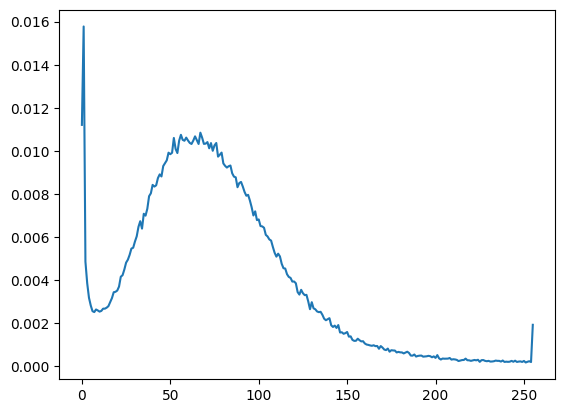

In [42]:
plt.plot(b_hist_norm)

In [43]:
import copy

image4 = copy.deepcopy(image3)

In [44]:

gamma_low = 0.5
image_gamma_low = np.array(255 * (image4 / 255.0) ** gamma_low, dtype='uint8')
   

In [45]:
gamma_high = 1.5
image_gamma_high = np.array(255 * (image4 / 255.0) ** gamma_high, dtype='uint8')

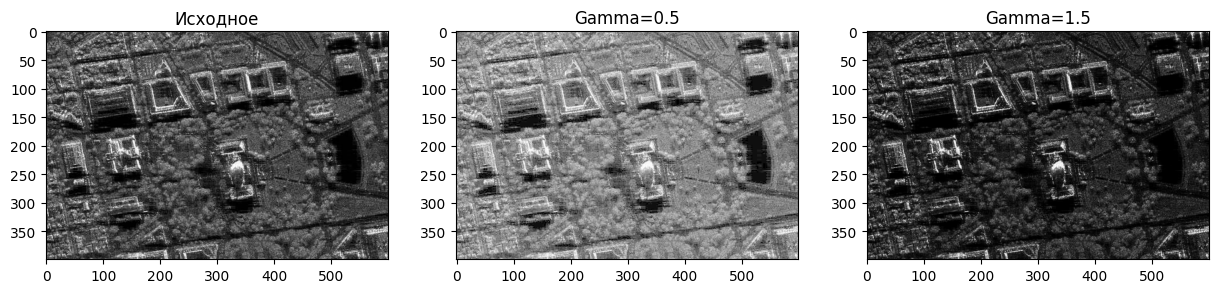

In [46]:


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(image4)
plt.title("Исходное")

plt.subplot(1,3,2)
plt.imshow(image_gamma_low)
plt.title(f"Gamma={gamma_low}")

plt.subplot(1,3,3)
plt.imshow(image_gamma_high)
plt.title(f"Gamma={gamma_high}")

plt.show()

In [47]:
image4_gray = cv2.cvtColor(image4, cv2.COLOR_BGR2GRAY) 
image_gamma_low_gray = cv2.cvtColor(image_gamma_low, cv2.COLOR_BGR2GRAY) 

In [48]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim_low, diff_low) = structural_similarity(image4_gray, image_gamma_low_gray, full=True)
diff_low = (diff_low * 255).astype("uint8")

print("SSIM: {}".format(ssim_low))

SSIM: 0.7875008686792753


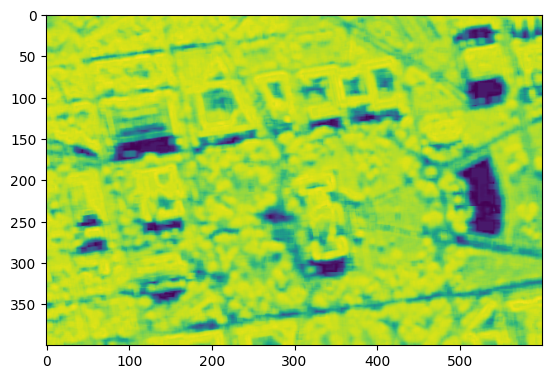

In [49]:
plt.imshow(diff_low)

In [50]:
image_gamma_high_gray = cv2.cvtColor(image_gamma_high, cv2.COLOR_BGR2GRAY) 

In [52]:
(ssim_high, diff_high) = structural_similarity(image4_gray, image_gamma_high_gray, full=True)
diff_high = (diff_high * 255).astype("uint8")

print("SSIM: {}".format(ssim_high))

SSIM: 0.8065788107754002


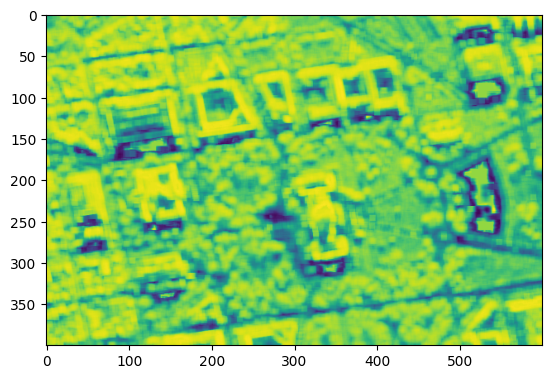

In [53]:
plt.imshow(diff_high)

In [54]:
mse_low = mean_squared_error(image4_gray, image_gamma_low_gray)
mse_low

np.float64(3250.429145833333)

In [55]:
mse_high = mean_squared_error(image4_gray, image_gamma_high_gray)
mse_high

np.float64(971.8206541666667)

In [56]:
eq_gray = cv2.equalizeHist(image4_gray)

74.94157083333333 43.658465466227916


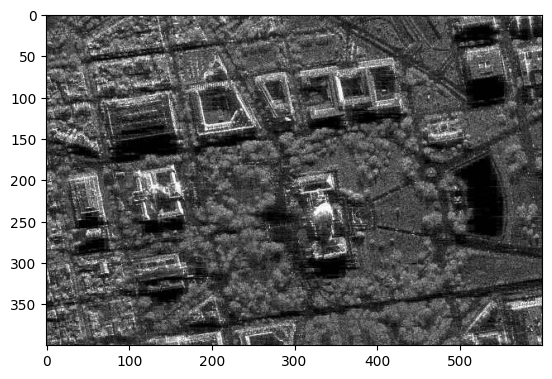

In [68]:
mean = image4_gray.mean()
std = image4_gray.std()
print(mean,std)
eq_gray = cv2.equalizeHist(image4_gray)
plt.imshow(eq_gray, cmap="gray")
plt.imshow(image4_gray, cmap="gray")


mean_ref = eq_gray.mean()
std_ref = eq_gray.std()


In [59]:
mean_ref = eq_gray.mean()
std_ref = eq_gray.std()

mean_src = image4_gray.mean()
std_src = image4_gray.std()

In [60]:
print(mean_src, std_src)
print(mean_ref, std_ref)

74.94157083333333 43.658465466227916
127.02563333333333 74.26964841889017


In [61]:
image4_stat_corr = (image4_gray - mean_src) * (std_ref / std_src) + mean_ref
image4_stat_corr = np.clip(image4_stat_corr, 0, 255).astype(np.uint8)

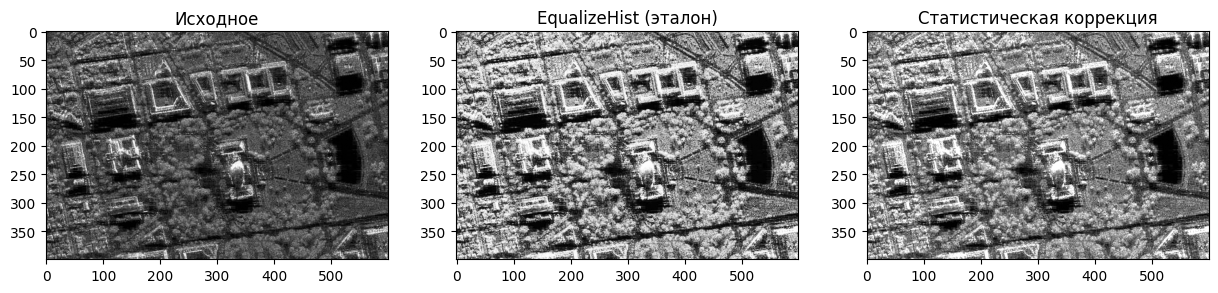

In [62]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(image4_gray, cmap="gray")
plt.title("Исходное")

plt.subplot(1,3,2)
plt.imshow(eq_gray, cmap="gray")
plt.title("EqualizeHist (эталон)")

plt.subplot(1,3,3)
plt.imshow(image4_stat_corr, cmap="gray")
plt.title("Статистическая коррекция")

plt.show()

np.uint64(0)

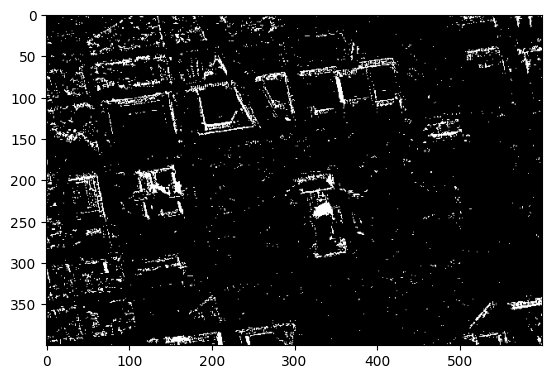

In [63]:
_, thresh_bin = cv2.threshold(image4_gray, 150, 255, cv2.THRESH_BINARY)
plt.imshow(thresh_bin, cmap='gray')
thresh_bin[thresh_bin==100].sum()

np.uint64(0)

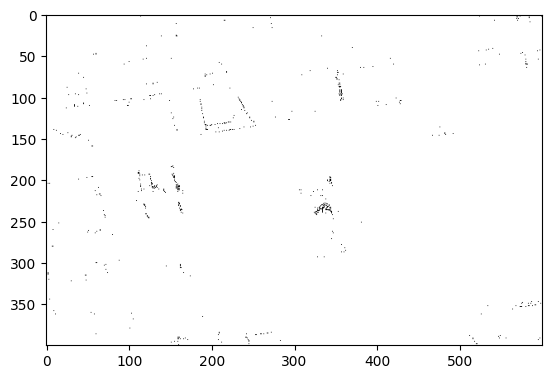

In [64]:
_, thresh_bin_inv = cv2.threshold(image4_gray, 250, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh_bin_inv, cmap='gray')
thresh_bin_inv[thresh_bin_inv==100].sum()

np.uint64(5728800)

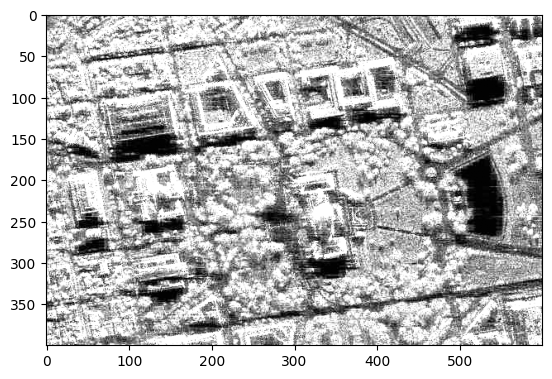

In [65]:
_, thresh_trunc = cv2.threshold(image4_gray, 100, 255, cv2.THRESH_TRUNC)
plt.imshow(thresh_trunc, cmap='gray')
thresh_trunc[thresh_trunc==100].sum()

np.uint64(0)

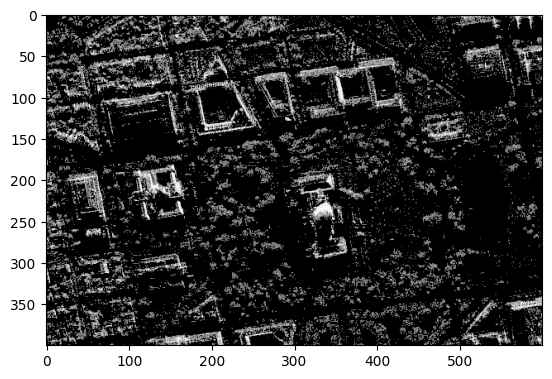

In [66]:
_, thresh_tozero = cv2.threshold(image4_gray, 100, 255, cv2.THRESH_TOZERO)
plt.imshow(thresh_tozero, cmap='gray')
thresh_tozero[thresh_tozero==100].sum()

np.uint64(163500)

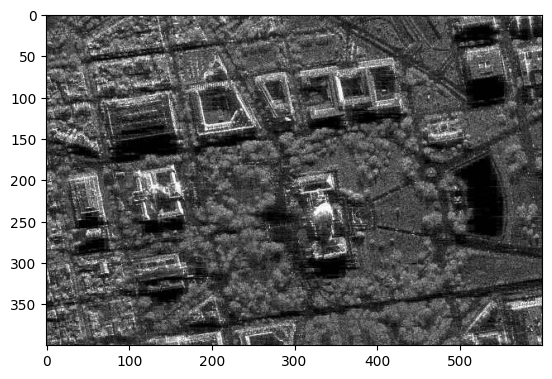

In [67]:
_, thresh_tozero_inv = cv2.threshold(image4_gray, 400, 255, cv2.THRESH_TOZERO_INV)
plt.imshow(thresh_tozero_inv, cmap='gray')
thresh_tozero_inv[thresh_tozero_inv==100].sum()